# Notebook 09.3: DenseNet121 Full Fine-Tune with AdamW

Single-backbone baseline with full fine-tuning from the start, matching the recent training style so results are easy to compare and ensemble later.


---
## Step 1: Imports


In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from torchvision.models import DenseNet121_Weights, densenet121

print("Imports OK")


Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and device


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")


Device: mps


## Step 3: Configuration


In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

NUM_WORKERS = 0
VAL_FRAC = 0.2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3

print(f"IMG_SIZE     : {IMG_SIZE}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"EPOCHS       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"WEIGHT_DECAY : {WEIGHT_DECAY}")
print(f"DROPOUT      : {DROPOUT}")


IMG_SIZE     : 256
BATCH_SIZE   : 4
EPOCHS       : 10
LR           : 0.0001
WEIGHT_DECAY : 0.0001
DROPOUT      : 0.3


## Step 4: Load labels


In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df[["image_file", "label"]].head())
print(df["label"].value_counts())


       image_file  label
0  IMG_000838.png      1
1  IMG_000239.png      1
2  IMG_000217.png      0
3  IMG_001193.png      0
4  IMG_001097.png      0
label
0    858
1    720
Name: count, dtype: int64


## Step 5: Dataset and transforms


In [5]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)

def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)


## Step 6: Train / validation split and loaders


In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=VAL_FRAC,
    stratify=df["label"],
    random_state=SEED,
)

print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")

train_tf = build_transform(IMG_SIZE, augment=True)
val_tf = build_transform(IMG_SIZE, augment=False)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")


Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)
Train batches: 316
Val   batches: 79


## Step 7: Metrics and training helpers


In [7]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold_score(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    best_thr, best_score = 0.5, -1.0
    for thr in np.linspace(0.01, 0.99, 199):
        sens, spec = sens_spec(y_true, y_prob, threshold=thr)
        score = datathon_score(auroc, sens, spec)
        if score > best_score:
            best_thr, best_score = thr, score
    return best_thr, best_score

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys)
    ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, train_loader, val_loader, optimizer, scheduler, epochs, device, tag="model", pos_weight_value=None):
    if pos_weight_value is None:
        pos_weight_value = train_df["label"].eq(0).sum() / train_df["label"].eq(1).sum()
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best = {"score": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        thr, tuned_score = best_threshold_score(val["y"], val["p"])
        sens_t, spec_t = sens_spec(val["y"], val["p"], threshold=thr)
        dt = time.time() - t0
        history.append({
            "epoch": epoch,
            "loss": tr_loss,
            "auroc": val["auroc"],
            "sens": sens_t,
            "spec": spec_t,
            "thr": thr,
            "score": tuned_score,
        })
        star = ""
        if tuned_score > best["score"]:
            best = {
                "score": tuned_score,
                "auroc": val["auroc"],
                "sens": sens_t,
                "spec": spec_t,
                "thr": thr,
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
            }
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        scheduler.step()
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {sens_t:.3f}  spec {spec_t:.3f}  "
            f"score {tuned_score:.4f}  thr {thr:.3f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best


## Step 8: Build full fine-tune model


In [8]:
def build_model(dropout=DROPOUT):
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(model.classifier.in_features, 1))
    return model

model = build_model().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")


Trainable: 6,954,881 / 6,954,881 (100.00%)


## Step 9: Train


In [9]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

model, history_df, best = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=EPOCHS,
    device=device,
    tag="densenet_fullft",
)

print("\nBest checkpoint:")
print(best)


[densenet_fullft] ep 01/10  loss 0.6588  AUROC 0.8484  sens 0.861  spec 0.715  score 0.8183  thr 0.604  (77.8s) ★


[densenet_fullft] ep 02/10  loss 0.5942  AUROC 0.8784  sens 0.847  spec 0.791  score 0.8487  thr 0.248  (64.2s) ★


[densenet_fullft] ep 03/10  loss 0.5408  AUROC 0.9429  sens 0.931  spec 0.831  score 0.9119  thr 0.589  (64.7s) ★


[densenet_fullft] ep 04/10  loss 0.4841  AUROC 0.9416  sens 0.938  spec 0.837  score 0.9145  thr 0.376  (64.6s) ★


[densenet_fullft] ep 05/10  loss 0.4481  AUROC 0.9248  sens 0.896  spec 0.808  score 0.8884  thr 0.129  (64.2s)


[densenet_fullft] ep 06/10  loss 0.4469  AUROC 0.9401  sens 0.924  spec 0.849  score 0.9132  thr 0.431  (65.4s)


[densenet_fullft] ep 07/10  loss 0.3556  AUROC 0.9390  sens 0.868  spec 0.884  score 0.9074  thr 0.718  (65.1s)


[densenet_fullft] ep 08/10  loss 0.3276  AUROC 0.9467  sens 0.931  spec 0.855  score 0.9196  thr 0.530  (65.8s) ★


[densenet_fullft] ep 09/10  loss 0.3139  AUROC 0.9420  sens 0.889  spec 0.884  score 0.9142  thr 0.436  (65.0s)


[densenet_fullft] ep 10/10  loss 0.2825  AUROC 0.9419  sens 0.896  spec 0.884  score 0.9159  thr 0.559  (64.8s)

Best checkpoint:
{'score': 0.9196342054263567, 'auroc': 0.9466650516795865, 'sens': 0.9305555555555556, 'spec': 0.8546511627906976, 'thr': np.float64(0.5296969696969697), 'state': OrderedDict([('features.conv0.weight', tensor([[[[ 7.8521e-02,  1.4952e-01,  1.6627e-01,  ...,  1.7715e-01,
            1.6622e-01,  1.4126e-01],
          [ 1.7534e-01,  2.4381e-01,  2.4991e-01,  ...,  2.7458e-01,
            2.5258e-01,  2.2201e-01],
          [ 1.2305e-01,  1.6397e-01,  1.4902e-01,  ...,  1.6299e-01,
            1.6194e-01,  1.4068e-01],
          ...,
          [-1.0492e-01, -1.2102e-01, -1.1969e-01,  ..., -1.1381e-01,
           -1.1208e-01, -1.1659e-01],
          [-1.4753e-01, -1.8672e-01, -1.8256e-01,  ..., -2.1684e-01,
           -2.0208e-01, -1.8277e-01],
          [-2.0742e-01, -2.7149e-01, -2.8171e-01,  ..., -2.8725e-01,
           -2.4895e-01, -2.2600e-01]],

         

## Step 10: Plot training history


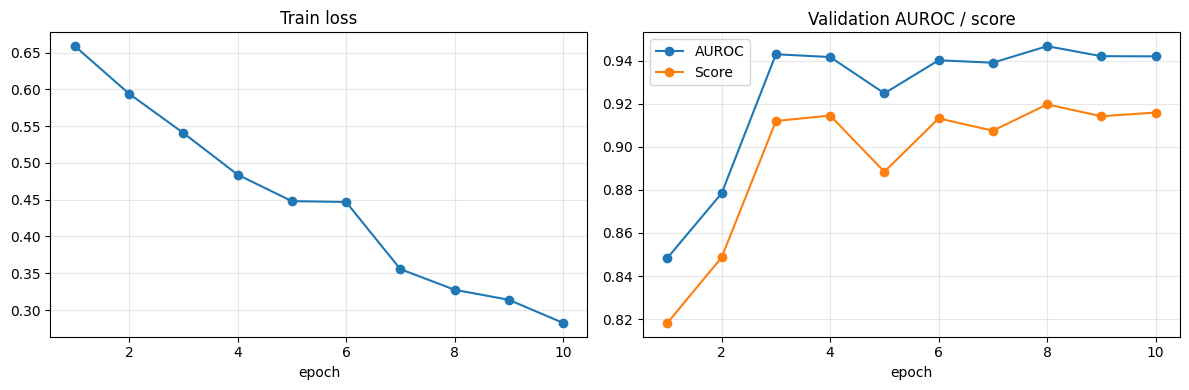

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["auroc"], marker="o", label="AUROC")
axes[1].plot(history_df["epoch"], history_df["score"], marker="o", label="Score")
axes[1].set_title("Validation AUROC / score")
axes[1].set_xlabel("epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


## Step 10.1: Overfitting Check (train vs validation)


     split      thr    score    auroc     sens     spec
train_eval 0.801919 0.984785 0.995399 0.968750 0.979592
       val 0.529697 0.919634 0.946665 0.930556 0.854651

Generalization gap:
  score gap : +0.0652
  AUROC gap : +0.0487
  sens gap  : +0.0382
  spec gap  : +0.1249


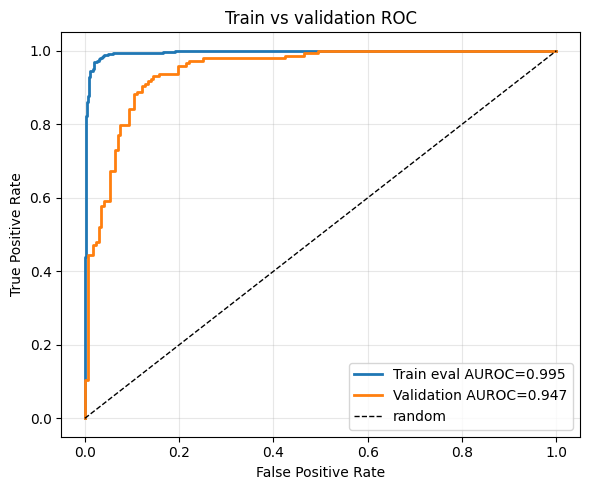

In [11]:
train_eval_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=build_transform(IMG_SIZE, augment=False))
train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

train_eval = evaluate(model, train_eval_loader, device)
train_thr, train_score = best_threshold_score(train_eval["y"], train_eval["p"])
train_sens, train_spec = sens_spec(train_eval["y"], train_eval["p"], threshold=train_thr)

val_eval = evaluate(model, val_loader, device)
val_thr, val_score = best_threshold_score(val_eval["y"], val_eval["p"])
val_sens, val_spec = sens_spec(val_eval["y"], val_eval["p"], threshold=val_thr)

overfit_df = pd.DataFrame([
    {
        "split": "train_eval",
        "thr": train_thr,
        "score": train_score,
        "auroc": train_eval["auroc"],
        "sens": train_sens,
        "spec": train_spec,
    },
    {
        "split": "val",
        "thr": val_thr,
        "score": val_score,
        "auroc": val_eval["auroc"],
        "sens": val_sens,
        "spec": val_spec,
    },
])
print(overfit_df.to_string(index=False))

print("\nGeneralization gap:")
print(f"  score gap : {train_score - val_score:+.4f}")
print(f"  AUROC gap : {train_eval['auroc'] - val_eval['auroc']:+.4f}")
print(f"  sens gap  : {train_sens - val_sens:+.4f}")
print(f"  spec gap  : {train_spec - val_spec:+.4f}")

plt.figure(figsize=(6, 5))
train_fpr, train_tpr, _ = roc_curve(train_eval["y"], train_eval["p"])
val_fpr, val_tpr, _ = roc_curve(val_eval["y"], val_eval["p"])
plt.plot(train_fpr, train_tpr, lw=2, label=f"Train eval AUROC={train_eval['auroc']:.3f}")
plt.plot(val_fpr, val_tpr, lw=2, label=f"Validation AUROC={val_eval['auroc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs validation ROC")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 11: Validation ROC and submission


          model      thr    score    auroc     sens     spec
densenet_fullft 0.529697 0.919634 0.946665 0.930556 0.854651


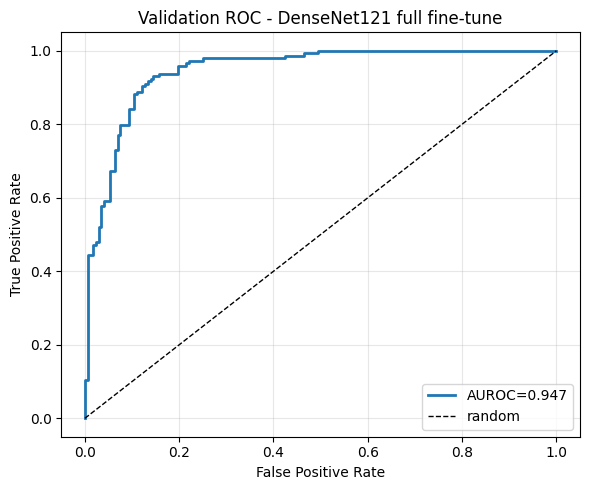

Test images: 176


test inference: 100%|██████████| 44/44 [00:03<00:00, 11.29it/s]


Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_09_3_densenet_fullft_20260421_2319.csv
       image_file      prob  pred
0  IMG_000018.png  0.859288     1
1  IMG_000021.png  0.018631     0
2  IMG_000039.png  0.638484     1
3  IMG_000044.png  0.052136     0
4  IMG_000047.png  0.271736     0

Positive rate in submission: 0.477


In [12]:
val = evaluate(model, val_loader, device)
best_thr, best_score = best_threshold_score(val["y"], val["p"])
best_sens, best_spec = sens_spec(val["y"], val["p"], threshold=best_thr)

summary_df = pd.DataFrame([
    {
        "model": 'densenet_fullft',
        "thr": best_thr,
        "score": best_score,
        "auroc": val["auroc"],
        "sens": best_sens,
        "spec": best_spec,
    }
])
print(summary_df.to_string(index=False))

fpr, tpr, _ = roc_curve(val["y"], val["p"])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUROC={val['auroc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Validation ROC - DenseNet121 full fine-tune')
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model.eval()
all_probs, all_names = [], []
with torch.no_grad():
    for imgs, names in tqdm(test_loader, desc="test inference"):
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_names.extend(names)

sub = pd.DataFrame({
    "image_file": all_names,
    "prob": all_probs,
})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_09_3_densenet_fullft_{stamp}.csv"
sub.to_csv(out_path, index=False)

print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")
